In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

In [2]:
data=pd.read_csv("Admission_Predict.csv")

In [3]:
data

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1,0.82
396,397,325,107,3,3.0,3.5,9.11,1,0.84
397,398,330,116,4,5.0,4.5,9.45,1,0.91
398,399,312,103,3,3.5,4.0,8.78,0,0.67


In [4]:
data.shape

(400, 9)

In [5]:
data=data.drop("Serial No.",axis=1)

In [6]:
data

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1,0.82
396,325,107,3,3.0,3.5,9.11,1,0.84
397,330,116,4,5.0,4.5,9.45,1,0.91
398,312,103,3,3.5,4.0,8.78,0,0.67


In [7]:
data.isnull().sum()

GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [9]:
data.columns=data.columns.str.strip()

In [10]:
def LabelEnc(x):
    if(x>=0.75):
        return 1
    else:
        return 0
data["Chance of Admit"]=data["Chance of Admit"].apply(LabelEnc)

In [11]:
data

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,1
1,324,107,4,4.0,4.5,8.87,1,1
2,316,104,3,3.0,3.5,8.00,1,0
3,322,110,3,3.5,2.5,8.67,1,1
4,314,103,2,2.0,3.0,8.21,0,0
...,...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1,1
396,325,107,3,3.0,3.5,9.11,1,1
397,330,116,4,5.0,4.5,9.45,1,1
398,312,103,3,3.5,4.0,8.78,0,0


In [12]:
x=data[["GRE Score","University Rating","CGPA"]]
y=data["Chance of Admit"]

In [13]:
x

,GRE Score,University Rating,CGPA
0,337,4,9.65
1,324,4,8.87
2,316,3,8.00
3,322,3,8.67
4,314,2,8.21
...,...,...,...
395,324,3,9.04
396,325,3,9.11
397,330,4,9.45
398,312,3,8.78


In [14]:
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.3,random_state=1)

In [15]:
gini_classifier=DecisionTreeClassifier(criterion="gini",max_depth=4)

In [16]:
entropy_classifier=DecisionTreeClassifier(criterion="entropy",max_depth=4)

In [18]:
gini_classifier.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=4)

In [19]:
entropy_classifier.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

In [20]:
gini_train_pred=gini_classifier.predict(x_train)
gini_test_pred=gini_classifier.predict(x_test)

entropy_train_pred=entropy_classifier.predict(x_train)
entropy_test_pred=entropy_classifier.predict(x_test)

Confusion Matrix of Training Based on gini index 



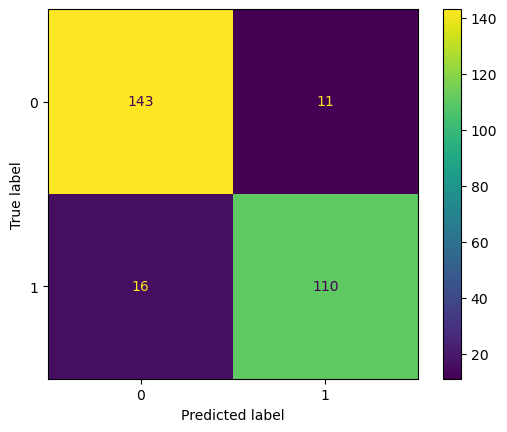

Classification Report (Training) 

              precision    recall  f1-score   support

           0       0.90      0.93      0.91       154
           1       0.91      0.87      0.89       126

    accuracy                           0.90       280
   macro avg       0.90      0.90      0.90       280
weighted avg       0.90      0.90      0.90       280

Confusion Matrix of Testing Based on gini index 



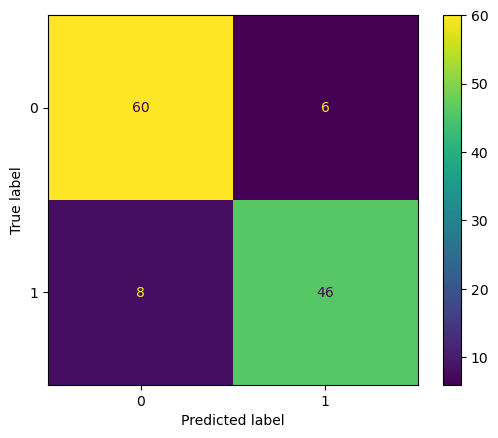

Classification Report (Testing) 

              precision    recall  f1-score   support

           0       0.88      0.91      0.90        66
           1       0.88      0.85      0.87        54

    accuracy                           0.88       120
   macro avg       0.88      0.88      0.88       120
weighted avg       0.88      0.88      0.88       120

Decision Tree Based on Gini Index 



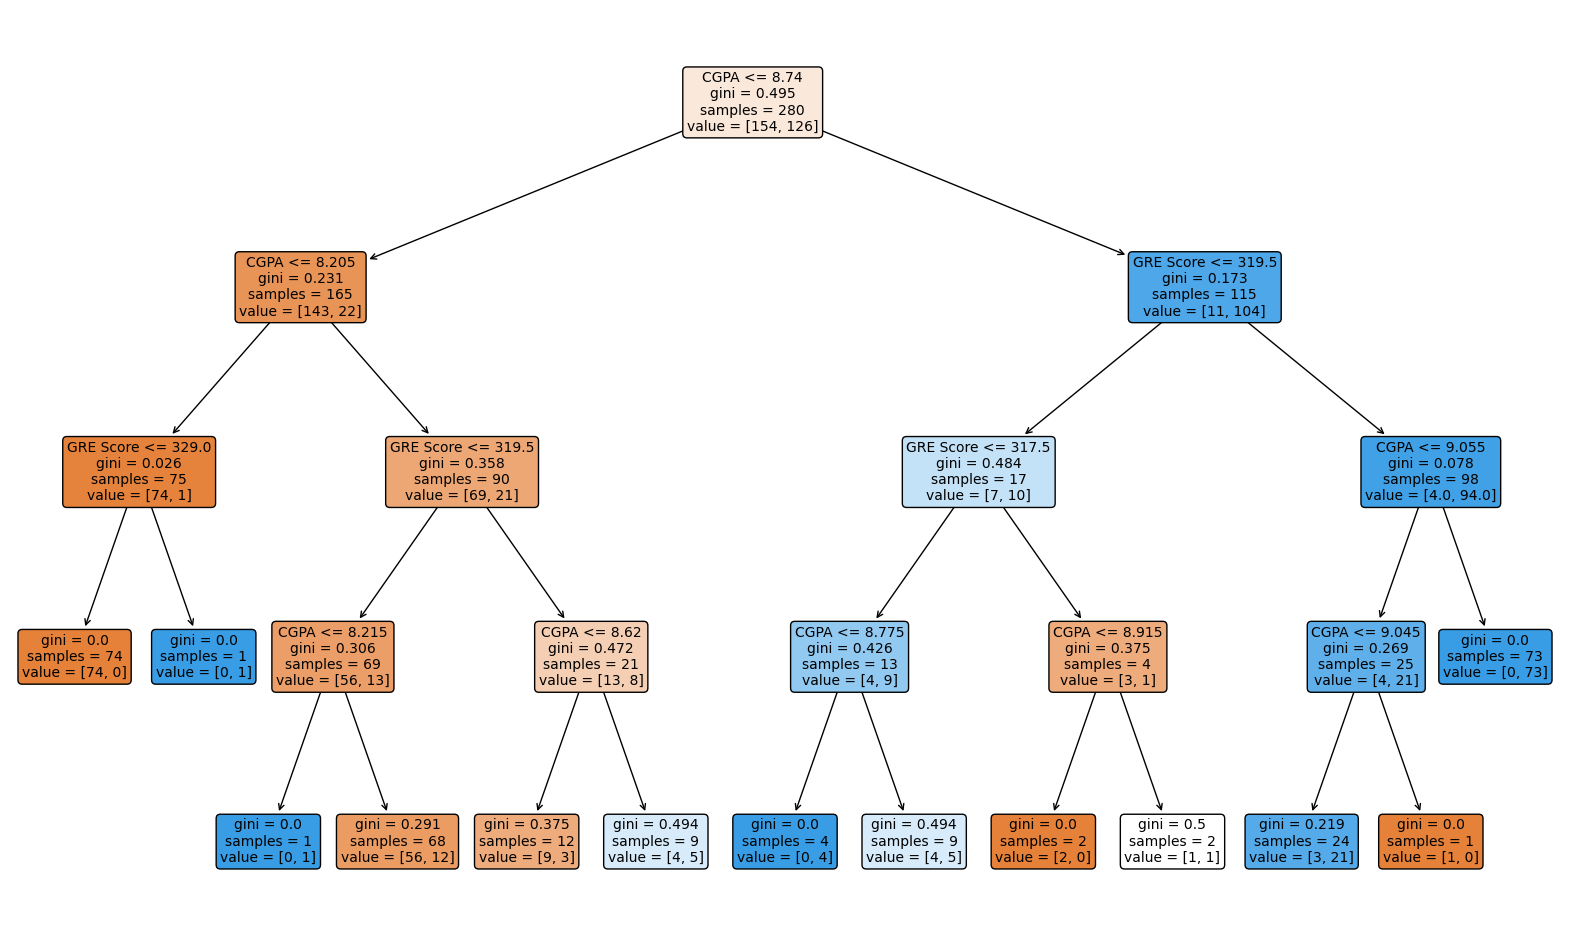

In [24]:
print("Confusion Matrix of Training Based on gini index \n")
ConfusionMatrixDisplay.from_predictions(y_train,gini_train_pred)
plt.show()
print("Classification Report (Training) \n")
print(classification_report(y_train,gini_train_pred))

print("Confusion Matrix of Testing Based on gini index \n")
ConfusionMatrixDisplay.from_predictions(y_test,gini_test_pred)
plt.show()
print("Classification Report (Testing) \n")
print(classification_report(y_test,gini_test_pred))

print("Decision Tree Based on Gini Index \n")
plt.figure(figsize=(20, 12))
plot_tree(gini_classifier,feature_names=x.columns,filled=True,rounded=True,fontsize=10)
plt.show()

Confusion Matrix of Training Based on Entropy 



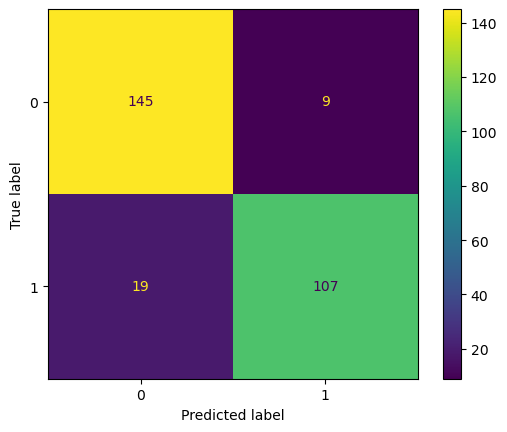

Classification Report (Training) 

              precision    recall  f1-score   support

           0       0.88      0.94      0.91       154
           1       0.92      0.85      0.88       126

    accuracy                           0.90       280
   macro avg       0.90      0.90      0.90       280
weighted avg       0.90      0.90      0.90       280

Confusion Matrix of Testing Based on Entropy 



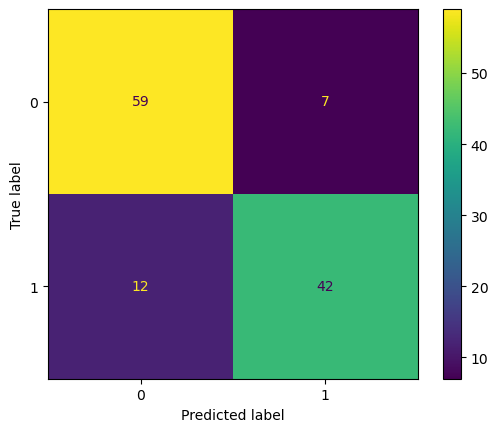

Classification Report (Testing) 

              precision    recall  f1-score   support

           0       0.83      0.89      0.86        66
           1       0.86      0.78      0.82        54

    accuracy                           0.84       120
   macro avg       0.84      0.84      0.84       120
weighted avg       0.84      0.84      0.84       120

Decision Tree Based on Entropy 



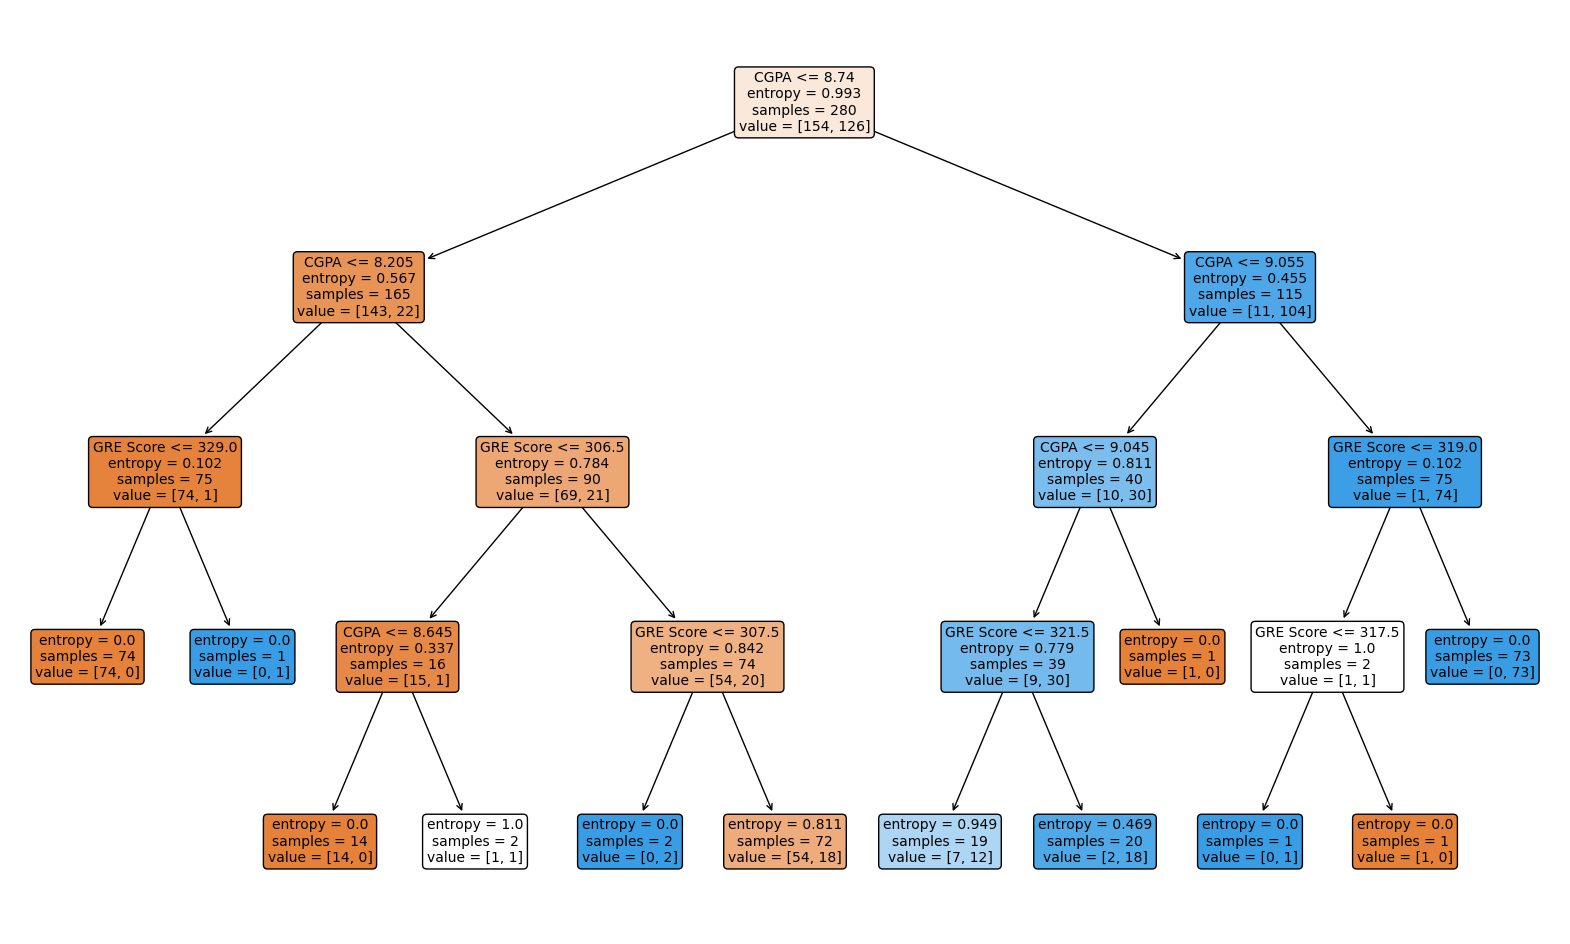

In [25]:
print("Confusion Matrix of Training Based on Entropy \n")
ConfusionMatrixDisplay.from_predictions(y_train,entropy_train_pred)
plt.show()
print("Classification Report (Training) \n")
print(classification_report(y_train,entropy_train_pred))

print("Confusion Matrix of Testing Based on Entropy \n")
ConfusionMatrixDisplay.from_predictions(y_test,entropy_test_pred)
plt.show()
print("Classification Report (Testing) \n")
print(classification_report(y_test,entropy_test_pred))

print("Decision Tree Based on Entropy \n")
plt.figure(figsize=(20, 12))
plot_tree(entropy_classifier,feature_names=x.columns,filled=True,rounded=True,fontsize=10)
plt.show()